In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [32]:
def load_space_group_data_from_csv(space_group_number):
    file_name = f"Group_subgroup/extracted_data_{space_group_number}.csv"
    try:
        data = pd.read_csv(file_name)
        return data[['IT number', 'HM symbol']]
    except FileNotFoundError:
        print(f"No data file found for space group {space_group_number}.")
        return None

In [33]:
# test User input
space_group_number = int(input("Enter the space group number: "))

# Load and display subgroups
subgroups = load_space_group_data_from_csv(space_group_number)
if subgroups is not None:
    print(subgroups)

Enter the space group number:  20


   IT number HM symbol
0          4       P21
1          5        C2
2         17     P2221
3         18    P21212
4         19   P212121
5         20     C2221
6         20     C2221
7         20     C2221


In [7]:
def generate_subgroup_flow(initial_sg, final_sg, max_depth=20, current_depth=0, visited=None):
    if visited is None:
        visited = set()

    if current_depth > max_depth:
        return []  # Limiting the recursion depth

    if initial_sg in visited:
        return []  # Avoid revisiting the same subgroup

    visited.add(initial_sg)
    if initial_sg == final_sg:
        return [[initial_sg]]

    subgroups = load_space_group_data_from_csv(initial_sg)
    if subgroups is None or subgroups.empty:
        return []

    paths = []
    for _, row in subgroups.iterrows():
        sg_number = row['IT number']
        for path in generate_subgroup_flow(sg_number, final_sg, max_depth, current_depth + 1, visited.copy()):
            paths.append([initial_sg] + path)

    return paths

In [10]:
# User input for initial and final space group numbers
initial_sg = int(input("Enter the initial space group number: "))
final_sg = int(input("Enter the final space group number: "))

# Generate and display the flow of subgroups
flows = generate_subgroup_flow(initial_sg, final_sg)
#filtered_flows = filter_redundant_paths(flows)
for flow in flows:
    print(" -> ".join(map(str, flow)))

Enter the initial space group number:  22
Enter the final space group number:  20


22 -> 20
22 -> 21 -> 16 -> 17 -> 20
22 -> 21 -> 17 -> 20
22 -> 21 -> 20
22 -> 21 -> 23 -> 16 -> 17 -> 20
22 -> 21 -> 24 -> 17 -> 20


In [11]:
def generate_subgroup_flow2(initial_sg, final_sg, max_depth=20, current_depth=0, visited=None, sg_map=None):
    if visited is None:
        visited = set()
    if sg_map is None:
        sg_map = {}

    # Limiting the recursion depth
    if current_depth > max_depth:
        print("Warning: Exceeded maximum calculation limit.")
        return []

    # Avoid revisiting the same subgroup
    if initial_sg in visited:
        return []  

    visited.add(initial_sg)

    # Load subgroups if not already done and update sg_map
    if initial_sg not in sg_map:
        subgroups_data = load_space_group_data_from_csv(initial_sg)
        if subgroups_data is None or subgroups_data.empty:
            return []

        for _, row in subgroups_data.iterrows():
            sg_number = row['IT number']
            sg_map[sg_number] = row['HM symbol']

    # Include both number and name in the path
    if initial_sg == final_sg:
        return [[(initial_sg, sg_map.get(initial_sg, 'Unknown'))]]

    paths = []
    subgroups_data = load_space_group_data_from_csv(initial_sg)  # Reload data for iteration
    if subgroups_data is not None and not subgroups_data.empty:
        for _, row in subgroups_data.iterrows():
            sg_number = row['IT number']
            sg_map[sg_number] = row['HM symbol']
            for path in generate_subgroup_flow2(sg_number, final_sg, max_depth, current_depth + 1, visited.copy(), sg_map):
                paths.append([(initial_sg, sg_map.get(initial_sg, 'Unknown'))] + path)

    return paths

In [12]:
flows = generate_subgroup_flow2(initial_sg, final_sg)
for flow in flows:
    print(" -> ".join(map(str, flow)))

(22, 'F222') -> (20, 'C2221')
(22, 'F222') -> (21, 'C222') -> (16, 'P222') -> (17, 'P2221') -> (20, 'C2221')
(22, 'F222') -> (21, 'C222') -> (17, 'P2221') -> (20, 'C2221')
(22, 'F222') -> (21, 'C222') -> (20, 'C2221')
(22, 'F222') -> (21, 'C222') -> (23, 'I222') -> (16, 'P222') -> (17, 'P2221') -> (20, 'C2221')
(22, 'F222') -> (21, 'C222') -> (24, 'I212121') -> (17, 'P2221') -> (20, 'C2221')


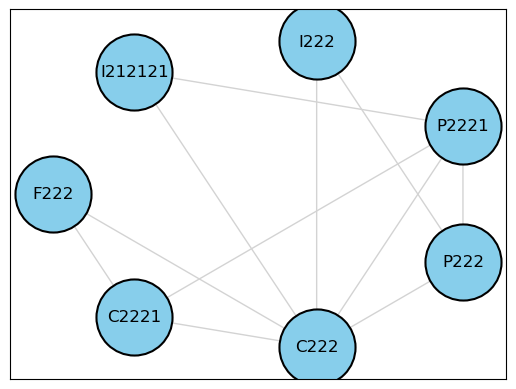

In [13]:
def create_flow_graph(flows):
    G = nx.DiGraph()

    # Add nodes and edges to the graph
    for flow in flows:
        for i in range(len(flow) - 1):
            current_node = flow[i]
            next_node = flow[i + 1]
            G.add_node(current_node[0], label=current_node[1])
            G.add_edge(current_node[0], next_node[0])
            
            # Make sure the final node is also added if it doesn't have outgoing edges
            if i == len(flow) - 2:  # If next_node is the last in the flow
                G.add_node(next_node[0], label=next_node[1])
    return G

def draw_graph(G):
    pos = nx.shell_layout(G)
    nx.draw_networkx_edges(G, pos, edge_color="lightgrey")

    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue', linewidths=1.5, edgecolors="black")
    nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'))

    plt.show()
    
flow_graph = create_flow_graph(flows)
draw_graph(flow_graph)

## I'm going to try creating a single graph for everything

In [14]:
from networkx.algorithms.traversal.depth_first_search import dfs_tree
from networkx.algorithms.simple_paths import all_simple_paths

In [15]:
G = nx.DiGraph()

In [16]:
subgroups = []
for n in range(1, 231):
    data = load_space_group_data_from_csv(n)
    data = data.drop_duplicates()

    for i in data["IT number"]:
        G.add_edge(n, i)

In [17]:
tree = dfs_tree(G, source=22, depth_limit=20)

In [18]:
subg = G.subgraph(tree.nodes)

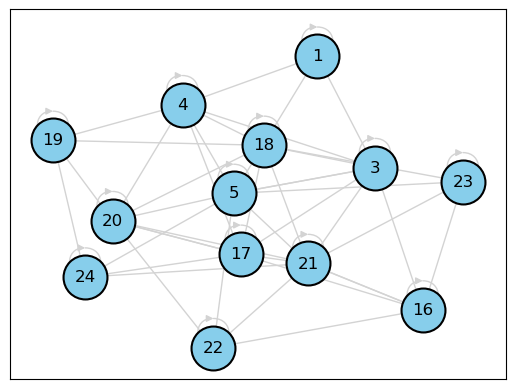

In [19]:
pos = nx.kamada_kawai_layout(subg)
# nx.draw_networkx_nodes(subg, pos=pos)
labels = {i: str(i) for i in subg.nodes}
nx.draw_networkx_edges(subg, pos, edge_color="lightgrey")
nx.draw_networkx_nodes(subg, pos, node_size=1000, node_color='skyblue', linewidths=1.5, edgecolors="black")
nx.draw_networkx_labels(subg, pos, labels=labels)

plt.show()

### Simple paths

In [20]:
paths = list(all_simple_paths(G, source=22, target=20))
nodes = set([i for path in paths for i in path])

In [21]:
subg = G.subgraph(nodes)

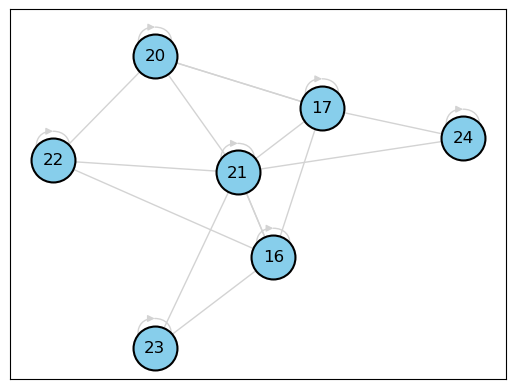

In [22]:
pos = nx.kamada_kawai_layout(subg)
# nx.draw_networkx_nodes(subg, pos=pos)
labels = {i: str(i) for i in subg.nodes}
nx.draw_networkx_edges(subg, pos, edge_color="lightgrey")
nx.draw_networkx_nodes(subg, pos, node_size=1000, node_color='skyblue', linewidths=1.5, edgecolors="black")
nx.draw_networkx_labels(subg, pos, labels=labels)

plt.show()

### Naming the graph

In [23]:
names = []
for n in range(1, 231):
    data = load_space_group_data_from_csv(n)
    data = data.drop_duplicates()
    names.append(data)
    
names = pd.concat(names, axis=0)
names = names.drop_duplicates().sort_values("IT number").set_index("IT number")
names = {i: row["HM symbol"] for i, row in names.iterrows()}

In [24]:
attrs = [names[i] for i in G.nodes]
nx.set_node_attributes(G, names, name="HM")

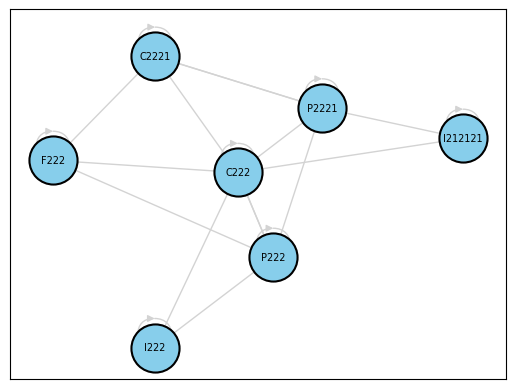

In [25]:
paths = list(all_simple_paths(G, source=22, target=20))
nodes = set([i for path in paths for i in path])
subg = G.subgraph(nodes)
pos = nx.kamada_kawai_layout(subg)

# Updating labels to use space group names instead of numbers
labels = {node: names[node] for node in subg.nodes}

nx.draw_networkx_edges(subg, pos, edge_color="lightgrey")
nx.draw_networkx_nodes(subg, pos, node_size=1200, node_color='skyblue', linewidths=1.5, edgecolors="black")
nx.draw_networkx_labels(subg, pos, labels=labels, font_size=7)

plt.show()

In [26]:
paths

[[22, 20],
 [22, 21, 16, 17, 20],
 [22, 21, 17, 20],
 [22, 21, 20],
 [22, 21, 23, 16, 17, 20],
 [22, 21, 24, 17, 20]]

In [28]:
space_group_df = pd.read_csv("Space Group Symmetries Tokens sheet 2.csv")

def find_symmetry_differences(group1, group2, space_group_df):
    # Extract the rows corresponding to each group
    group1_data = space_group_df[space_group_df['Number'] == group1].iloc[0]
    group2_data = space_group_df[space_group_df['Number'] == group2].iloc[0]
    
    # Find the columns that have different values
    differences = (group1_data != group2_data) & (group1_data.index != 'Number') & (group1_data.index != 'named')
    different_columns = group1_data.index[differences].tolist()
    
    # Create a dictionary of the differences
    diff_dict = {column: (group1_data[column], group2_data[column]) for column in different_columns}
    
    return diff_dict

symmetry_differences = {}

for path in paths:
    symmetry_diff_path = []
    for i in range(len(path) - 1):
        diff = find_symmetry_differences(path[i], path[i+1], space_group_df)
        symmetry_diff_path.append((path[i], path[i+1], diff))
    symmetry_differences[str(path)] = symmetry_diff_path

In [29]:
symmetry_differences.keys()

dict_keys(['[22, 20]', '[22, 21, 16, 17, 20]', '[22, 21, 17, 20]', '[22, 21, 20]', '[22, 21, 23, 16, 17, 20]', '[22, 21, 24, 17, 20]'])

In [30]:
symmetry_differences["[22, 21, 16, 17, 20]"]

[(22,
  21,
  {'Point Group': (nan, nan),
   'Short Name': ('F222', 'C222'),
   'Bravais_lattice_C': (0, 1),
   'Bravais_lattice_F': (1, 0)}),
 (21,
  16,
  {'Point Group': (nan, '222'),
   'Short Name': ('C222', 'P222'),
   'Bravais_lattice_P': (0, 1),
   'Bravais_lattice_C': (1, 0)}),
 (16,
  17,
  {'Point Group': ('222', nan),
   'Short Name': ('P222', 'P2221'),
   'C_2': (1, 0),
   'C_21': (0, 1)}),
 (17,
  20,
  {'Point Group': (nan, nan),
   'Short Name': ('P2221', 'C2221'),
   'Bravais_lattice_P': (1, 0),
   'Bravais_lattice_C': (0, 1)})]

In [31]:
symmetry_differences["[22, 21, 16, 17, 20]"][0][-1]

{'Point Group': (nan, nan),
 'Short Name': ('F222', 'C222'),
 'Bravais_lattice_C': (0, 1),
 'Bravais_lattice_F': (1, 0)}